# OCNG 689 demo notebook: removing the M2 tide from a noisy 1D SSH time series with classical harmonic analysis and machine learning

This notebook is a **fully synthetic, fully reproducible** demonstration of how to estimate and subtract the dominant **M2 tide** from a noisy sea-surface-height (SSH) time series.

## What this notebook is designed to teach

1. **Physics:** the M2 constituent is the principal lunar semidiurnal tide.
2. **Signal processing:** a classical harmonic fit is a narrowband sinusoidal model.
3. **Machine learning:** a local-window neural network can learn to reconstruct the M2 signal from noisy observations **without being explicitly given the M2 frequency**.
4. **Oceanography context:** tides are a major correction term in satellite altimetry and in many oceanographic SSH applications.

## Scientific context and references

- NOAA CO-OPS explains harmonic constituents and notes that **M2 is the largest lunar constituent** in standard tidal prediction practice:  
  <https://tidesandcurrents.noaa.gov/about_harmonic_constituents.html>
- NOAA harmonic constituent tables list **M2 speed = 28.984104° hr$^{-1}$**, which corresponds to a period of about **12.4206 h**:  
  <https://tidesandcurrents.noaa.gov/harcon.html?id=1770000>
- NOAA's *Tidal Analysis and Predictions* manual provides the harmonic-analysis background used in operational tide work:  
  <https://tidesandcurrents.noaa.gov/publications/Tidal_Analysis_and_Predictions.pdf>
- AVISO notes that satellite altimetry requires multiple geophysical corrections, including tides:  
  <https://www.aviso.altimetry.fr/en/data/products/ocean-indicators-products/mean-sea-level/processing-and-corrections.html>
- JPL's Ocean Surface Topography program notes that tidal atlases are used for **altimeter tide corrections**, and also points out that traditional point-wise harmonic analysis can be limited when tides are contaminated by mesoscale variability:  
  <https://sealevel.jpl.nasa.gov/documents/1690/>  
  <https://sealevel.jpl.nasa.gov/documents/1623/>

> **Pedagogical note:** this notebook is intentionally 1D and synthetic. It is not a production tide-correction system for real altimetry data, but it is a rigorous sandbox for understanding the problem.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    "figure.figsize": (10, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.options.display.float_format = "{:,.4f}".format

RNG_SEED = 689
np.random.seed(RNG_SEED)

## 1. Constants and helper functions

We work in **hours** for the time coordinate and in **meters** for SSH.

The M2 constituent speed from NOAA is \(28.984104^\circ\ \mathrm{hr}^{-1}\), so

\[
T_{M2} = \frac{360^\circ}{28.984104^\circ\ \mathrm{hr}^{-1}} \approx 12.4206\ \mathrm{h}.
\]

The synthetic observed SSH is

\[
\eta_{\mathrm{obs}}(t) = \eta_{M2}(t) + \eta_{\mathrm{low}}(t) + \eta_{\mathrm{noise}}(t),
\]

with optional missing data, small frequency mismatch, and optional nonstationary M2 amplitude modulation.

In [2]:
M2_SPEED_DEG_PER_HOUR = 28.9841042
M2_PERIOD_HOURS = 360.0 / M2_SPEED_DEG_PER_HOUR
M2_FREQUENCY_CPD = 24.0 / M2_PERIOD_HOURS
M2_OMEGA = 2.0 * np.pi / M2_PERIOD_HOURS

S2_PERIOD_HOURS = 12.0
S2_OMEGA = 2.0 * np.pi / S2_PERIOD_HOURS
S2_FREQUENCY_CPD = 24.0 / S2_PERIOD_HOURS


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def variance_explained(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(1.0 - np.var(y_true - y_pred) / np.var(y_true))


def finite_interpolate(y):
    y = np.asarray(y, dtype=float).copy()
    x = np.arange(y.size)
    mask = np.isfinite(y)
    if mask.all():
        return y
    if mask.sum() == 0:
        return np.zeros_like(y)
    y[~mask] = np.interp(x[~mask], x[mask], y[mask])
    return y


def apply_missing_blocks(y, missing_fraction=0.0, min_block=3, max_block=12, rng=None):
    y = np.asarray(y, dtype=float).copy()
    n = y.size
    mask = np.ones(n, dtype=bool)

    if missing_fraction <= 0.0:
        return y, mask

    if rng is None:
        rng = np.random.default_rng()

    target_missing = int(np.floor(missing_fraction * n))
    inserted = 0
    attempts = 0

    while inserted < target_missing and attempts < 20 * n:
        attempts += 1
        block = int(rng.integers(min_block, max_block + 1))
        start = int(rng.integers(0, max(1, n - block)))
        end = min(n, start + block)

        newly_removed = mask[start:end].sum()
        mask[start:end] = False
        inserted += newly_removed

    y[~mask] = np.nan
    return y, mask


def m2_component(t_hours, amplitude=0.5, phase_deg=30.0, freq_scale=1.0, amplitude_modulation=False):
    phase_rad = np.deg2rad(phase_deg)
    envelope = np.ones_like(t_hours, dtype=float) * amplitude

    if amplitude_modulation:
        # A slowly varying envelope that deliberately violates the stationary-amplitude assumption.
        envelope = amplitude * (1.0 + 0.30 * np.cos(2.0 * np.pi * t_hours / (24.0 * 14.0) + 0.7))
        envelope = np.clip(envelope, 0.05 * amplitude, None)

    return envelope * np.cos(freq_scale * M2_OMEGA * t_hours + phase_rad)


def low_frequency_component(t_hours, amplitude=0.2):
    return amplitude * (
        0.65 * np.cos(2.0 * np.pi * t_hours / (24.0 * 5.5) + 1.1)
        + 0.35 * np.sin(2.0 * np.pi * t_hours / (24.0 * 9.0) - 0.3)
    )


def generate_synthetic_record(
    days=45,
    dt_hours=1.0,
    m2_amplitude=0.5,
    m2_phase_deg=30.0,
    noise_std=0.15,
    low_freq_amplitude=0.2,
    missing_fraction=0.0,
    freq_scale=1.0,
    amplitude_modulation=False,
    s2_amplitude=0.0,
    seed=None,
):
    rng = np.random.default_rng(seed)

    t_hours = np.arange(0.0, days * 24.0 + 1e-12, dt_hours)

    m2 = m2_component(
        t_hours,
        amplitude=m2_amplitude,
        phase_deg=m2_phase_deg,
        freq_scale=freq_scale,
        amplitude_modulation=amplitude_modulation,
    )
    s2 = s2_amplitude * np.cos(S2_OMEGA * t_hours + 0.4)
    low = low_frequency_component(t_hours, amplitude=low_freq_amplitude)
    noise = rng.normal(0.0, noise_std, size=t_hours.size)

    observed_no_gaps = m2 + s2 + low + noise
    observed, mask = apply_missing_blocks(observed_no_gaps, missing_fraction=missing_fraction, rng=rng)

    return {
        "t_hours": t_hours,
        "dt_hours": dt_hours,
        "m2_true": m2,
        "s2_true": s2,
        "low_true": low,
        "noise": noise,
        "observed_no_gaps": observed_no_gaps,
        "observed": observed,
        "mask": mask,
    }


def spectrum_cpd(y, dt_hours=1.0, nperseg=None):
    y_filled = finite_interpolate(y)
    fs = 24.0 / dt_hours  # samples per day
    if nperseg is None:
        nperseg = min(256, len(y_filled))
    freq_cpd, psd = welch(
        y_filled - np.nanmean(y_filled),
        fs=fs,
        nperseg=nperseg,
        detrend="linear",
    )
    return freq_cpd, psd


def m2_band_power(freq_cpd, psd, center_cpd=M2_FREQUENCY_CPD, width=0.10):
    idx = np.abs(freq_cpd - center_cpd) <= width
    if not np.any(idx):
        return np.nan
    return float(np.trapezoid(psd[idx], freq_cpd[idx]))


def fit_harmonic_ls(t_hours, y, omega=M2_OMEGA, include_intercept=True):
    t = np.asarray(t_hours, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(y)

    cols = [np.cos(omega * t[valid]), np.sin(omega * t[valid])]
    if include_intercept:
        cols.append(np.ones(valid.sum()))
    X = np.column_stack(cols)

    beta, *_ = np.linalg.lstsq(X, y[valid], rcond=None)
    a = beta[0]
    b = beta[1]
    c = beta[2] if include_intercept else 0.0

    prediction = a * np.cos(omega * t) + b * np.sin(omega * t) + c

    amplitude = float(np.hypot(a, b))
    phase_deg = float(np.rad2deg(np.arctan2(-b, a)))  # because A cos(wt + phi) = a cos(wt) + b sin(wt)

    return {
        "a": float(a),
        "b": float(b),
        "c": float(c),
        "amplitude": amplitude,
        "phase_deg": phase_deg,
        "prediction": prediction,
    }


def fit_multifrequency_ls(t_hours, y, omegas, include_intercept=True):
    t = np.asarray(t_hours, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(y)

    cols = []
    for omega in omegas:
        cols.append(np.cos(omega * t[valid]))
        cols.append(np.sin(omega * t[valid]))
    if include_intercept:
        cols.append(np.ones(valid.sum()))

    X = np.column_stack(cols)
    beta, *_ = np.linalg.lstsq(X, y[valid], rcond=None)

    prediction = np.zeros_like(t)
    cursor = 0
    for omega in omegas:
        a = beta[cursor]
        b = beta[cursor + 1]
        prediction += a * np.cos(omega * t) + b * np.sin(omega * t)
        cursor += 2
    if include_intercept:
        prediction += beta[-1]

    return {"beta": beta, "prediction": prediction}


def sliding_window_features(y, window=49, mask=None):
    y = np.asarray(y, dtype=float)
    filled = finite_interpolate(y)

    if mask is None:
        mask_arr = np.isfinite(y).astype(float)
    else:
        mask_arr = np.asarray(mask, dtype=float)

    half = window // 2
    y_pad = np.pad(filled, (half, half), mode="edge")
    m_pad = np.pad(mask_arr, (half, half), mode="edge")

    X = np.empty((len(y), window * 2), dtype=float)
    for i in range(len(y)):
        X[i, :window] = y_pad[i : i + window]
        X[i, window:] = m_pad[i : i + window]
    return X


def build_training_dataset(
    n_records=60,
    days=10,
    dt_hours=1.0,
    window=49,
    stride=3,
    seed=689,
    include_amp_mod_prob=0.25,
    include_freq_jitter=True,
    include_missing=True,
):
    rng = np.random.default_rng(seed)

    X_list = []
    y_list = []

    for _ in range(n_records):
        rec = generate_synthetic_record(
            days=days,
            dt_hours=dt_hours,
            m2_amplitude=float(rng.uniform(0.20, 0.90)),
            m2_phase_deg=float(rng.uniform(-180.0, 180.0)),
            noise_std=float(rng.uniform(0.05, 0.35)),
            low_freq_amplitude=float(rng.uniform(0.05, 0.30)),
            missing_fraction=float(rng.uniform(0.00, 0.30)) if include_missing else 0.0,
            freq_scale=float(rng.uniform(0.996, 1.004)) if include_freq_jitter else 1.0,
            amplitude_modulation=bool(rng.random() < include_amp_mod_prob),
            s2_amplitude=float(rng.uniform(0.00, 0.08)),
            seed=int(rng.integers(1, 1_000_000_000)),
        )

        X = sliding_window_features(rec["observed"], window=window, mask=rec["mask"])
        y = rec["m2_true"]

        idx = np.arange(window // 2, len(y) - window // 2, stride)
        X_list.append(X[idx])
        y_list.append(y[idx])

    return np.vstack(X_list), np.concatenate(y_list)


def train_mlp_tide_model(X_train, y_train, random_state=689):
    model = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "mlp",
                MLPRegressor(
                    hidden_layer_sizes=(48, 24),
                    activation="relu",
                    solver="adam",
                    alpha=5e-4,
                    batch_size=256,
                    learning_rate_init=2e-3,
                    max_iter=250,
                    early_stopping=True,
                    validation_fraction=0.15,
                    n_iter_no_change=15,
                    random_state=random_state,
                ),
            ),
        ]
    )
    model.fit(X_train, y_train)
    return model


def predict_mlp_record(model, rec, window=49):
    X = sliding_window_features(rec["observed"], window=window, mask=rec["mask"])
    return model.predict(X)


def evaluate_record_models(rec, model, window=49, harmonic_omega=M2_OMEGA):
    harmonic = fit_harmonic_ls(rec["t_hours"], rec["observed"], omega=harmonic_omega)
    mlp_prediction = predict_mlp_record(model, rec, window=window)

    return {
        "rmse_harmonic": rmse(rec["m2_true"], harmonic["prediction"]),
        "rmse_mlp": rmse(rec["m2_true"], mlp_prediction),
        "ve_harmonic": variance_explained(rec["m2_true"], harmonic["prediction"]),
        "ve_mlp": variance_explained(rec["m2_true"], mlp_prediction),
        "harmonic_pred": harmonic["prediction"],
        "mlp_pred": mlp_prediction,
    }


def m2_band_reduction(y_before, y_after, dt_hours=1.0):
    f0, p0 = spectrum_cpd(y_before, dt_hours=dt_hours)
    f1, p1 = spectrum_cpd(y_after, dt_hours=dt_hours)
    band0 = m2_band_power(f0, p0)
    band1 = m2_band_power(f1, p1)
    return float(100.0 * (1.0 - band1 / band0))


def alias_frequency(f_true_cpd, fs_cpd):
    # Fold frequency into the Nyquist interval [0, fs/2].
    return abs(((f_true_cpd + fs_cpd / 2.0) % fs_cpd) - fs_cpd / 2.0)

## 2. Generate one demonstration record

We create an hourly SSH time series with:
- one M2 constituent,
- one slowly varying low-frequency background term,
- additive Gaussian noise.

This first case is **stationary** and uses the exact M2 frequency. That is important, because under those conditions the classical harmonic model should be very strong.

In [3]:
demo = generate_synthetic_record(
    days=45,
    dt_hours=1.0,
    m2_amplitude=0.55,
    m2_phase_deg=35.0,
    noise_std=0.18,
    low_freq_amplitude=0.22,
    missing_fraction=0.0,
    freq_scale=1.0,
    amplitude_modulation=False,
    seed=123,
)

summary = pd.DataFrame(
    {
        "quantity": [
            "record length (days)",
            "sampling interval (hours)",
            "M2 period (hours)",
            "M2 frequency (cycles/day)",
            "true M2 amplitude (m)",
            "true M2 phase (deg)",
            "noise std (m)",
            "low-frequency amplitude scale (m)",
        ],
        "value": [
            45,
            demo["dt_hours"],
            M2_PERIOD_HOURS,
            M2_FREQUENCY_CPD,
            0.55,
            35.0,
            0.18,
            0.22,
        ],
    }
)
summary

,quantity,value
0,record length (days),45.0000
1,sampling interval (hours),1.0000
2,M2 period (hours),12.4206
3,M2 frequency (cycles/day),1.9323
4,true M2 amplitude (m),0.5500
5,true M2 phase (deg),35.0000
6,noise std (m),0.1800
7,low-frequency amplitude scale (m),0.2200


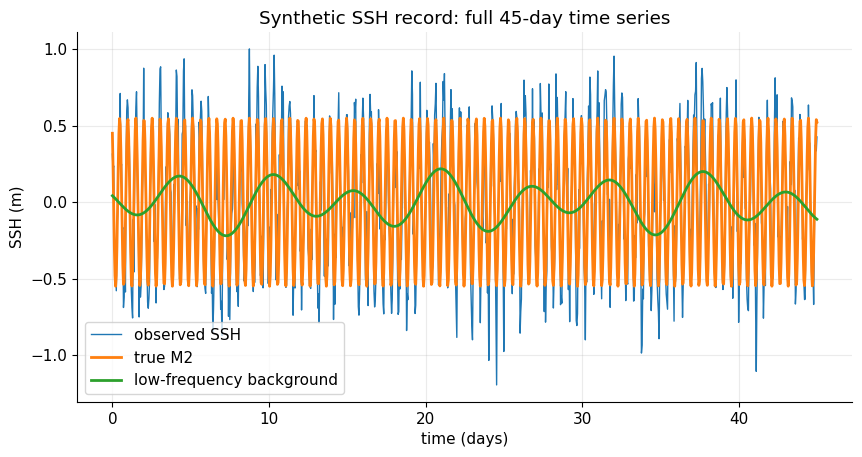

In [4]:
plt.figure()
plt.plot(demo["t_hours"] / 24.0, demo["observed"], label="observed SSH", linewidth=1.0)
plt.plot(demo["t_hours"] / 24.0, demo["m2_true"], label="true M2", linewidth=2.0)
plt.plot(demo["t_hours"] / 24.0, demo["low_true"], label="low-frequency background", linewidth=2.0)
plt.xlabel("time (days)")
plt.ylabel("SSH (m)")
plt.title("Synthetic SSH record: full 45-day time series")
plt.legend()
plt.show()

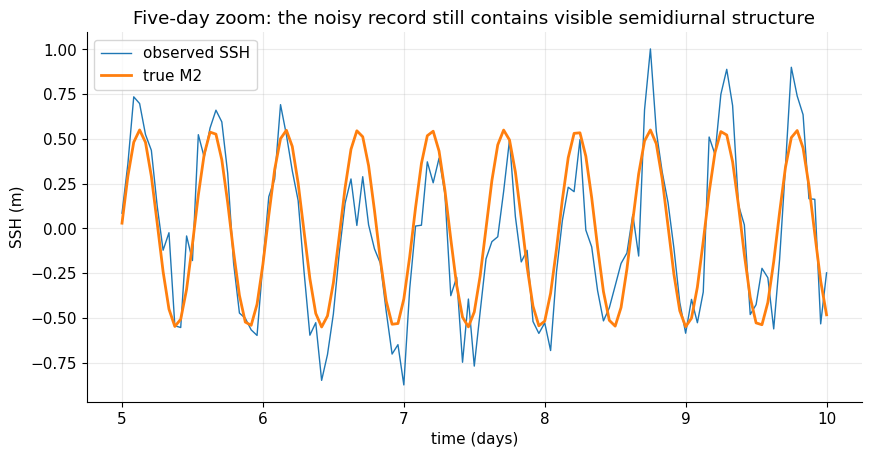

In [5]:
zoom = (demo["t_hours"] >= 5 * 24) & (demo["t_hours"] <= 10 * 24)

plt.figure()
plt.plot(demo["t_hours"][zoom] / 24.0, demo["observed"][zoom], label="observed SSH", linewidth=1.0)
plt.plot(demo["t_hours"][zoom] / 24.0, demo["m2_true"][zoom], label="true M2", linewidth=2.0)
plt.xlabel("time (days)")
plt.ylabel("SSH (m)")
plt.title("Five-day zoom: the noisy record still contains visible semidiurnal structure")
plt.legend()
plt.show()

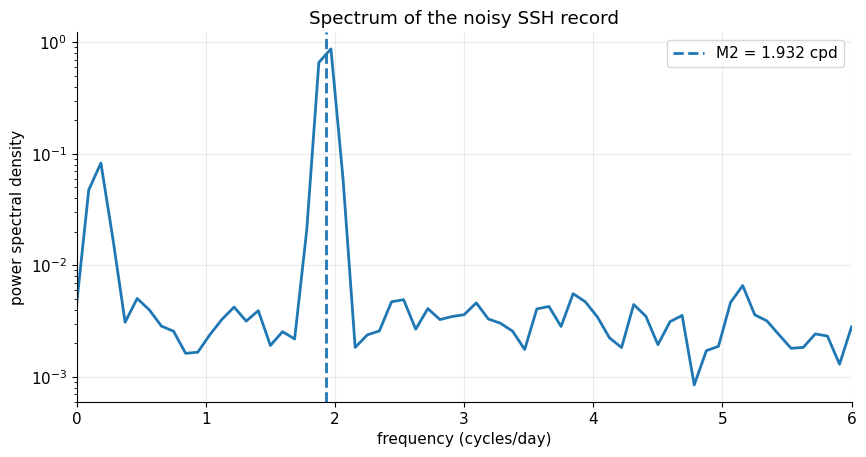

In [6]:
freq_cpd, psd = spectrum_cpd(demo["observed"], dt_hours=demo["dt_hours"])

plt.figure()
plt.semilogy(freq_cpd, psd, linewidth=2.0)
plt.axvline(M2_FREQUENCY_CPD, linestyle="--", linewidth=2.0, label=f"M2 = {M2_FREQUENCY_CPD:.3f} cpd")
plt.xlim(0, 6)
plt.xlabel("frequency (cycles/day)")
plt.ylabel("power spectral density")
plt.title("Spectrum of the noisy SSH record")
plt.legend()
plt.show()

## 3. Classical baseline: harmonic least squares at the known M2 frequency

A standard harmonic fit assumes

\[
\eta(t) \approx a \cos(\omega_{M2} t) + b \sin(\omega_{M2} t) + c.
\]

This is just least-squares regression on a fixed sinusoidal basis. If the signal is truly stationary and the constituent frequency is known, it is very difficult to beat.

In [7]:
harmonic = fit_harmonic_ls(demo["t_hours"], demo["observed"], omega=M2_OMEGA)

baseline_metrics = pd.DataFrame(
    {
        "metric": [
            "true amplitude (m)",
            "estimated amplitude (m)",
            "true phase (deg)",
            "estimated phase (deg)",
            "M2 RMSE (m)",
            "variance explained",
        ],
        "value": [
            0.55,
            harmonic["amplitude"],
            35.0,
            harmonic["phase_deg"],
            rmse(demo["m2_true"], harmonic["prediction"]),
            variance_explained(demo["m2_true"], harmonic["prediction"]),
        ],
    }
)
baseline_metrics

,metric,value
0,true amplitude (m),0.5500
1,estimated amplitude (m),0.5456
2,true phase (deg),35.0000
3,estimated phase (deg),35.2650
4,M2 RMSE (m),0.0069
5,variance explained,0.9999


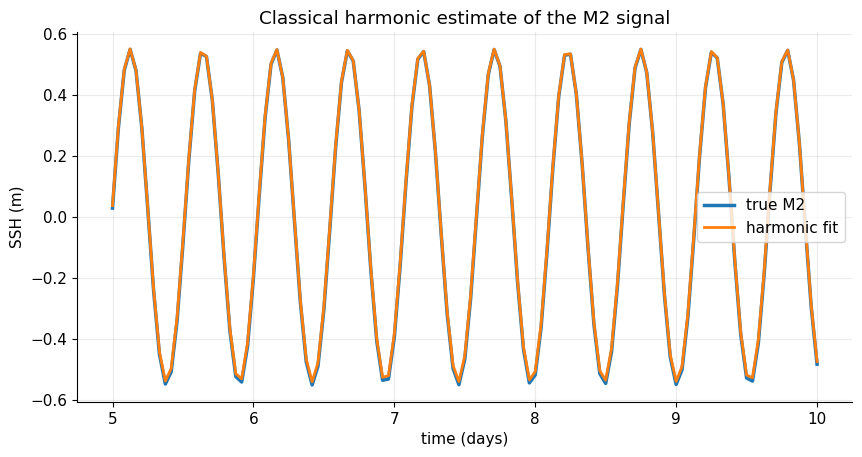

In [8]:
plt.figure()
plt.plot(demo["t_hours"][zoom] / 24.0, demo["m2_true"][zoom], label="true M2", linewidth=2.5)
plt.plot(demo["t_hours"][zoom] / 24.0, harmonic["prediction"][zoom], label="harmonic fit", linewidth=2.0)
plt.xlabel("time (days)")
plt.ylabel("SSH (m)")
plt.title("Classical harmonic estimate of the M2 signal")
plt.legend()
plt.show()

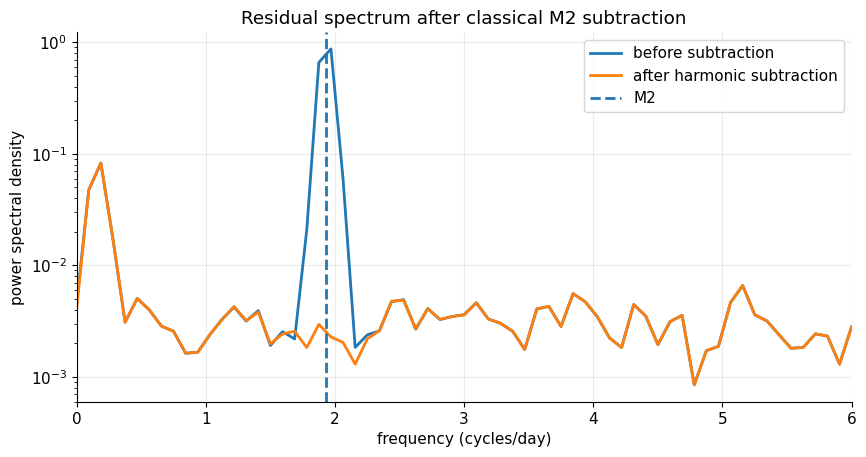

M2-band power reduction: 99.66%


In [9]:
harmonic_residual = demo["observed"] - harmonic["prediction"]

freq_before, psd_before = spectrum_cpd(demo["observed"], dt_hours=demo["dt_hours"])
freq_after, psd_after = spectrum_cpd(harmonic_residual, dt_hours=demo["dt_hours"])

plt.figure()
plt.semilogy(freq_before, psd_before, label="before subtraction", linewidth=2.0)
plt.semilogy(freq_after, psd_after, label="after harmonic subtraction", linewidth=2.0)
plt.axvline(M2_FREQUENCY_CPD, linestyle="--", linewidth=2.0, label="M2")
plt.xlim(0, 6)
plt.xlabel("frequency (cycles/day)")
plt.ylabel("power spectral density")
plt.title("Residual spectrum after classical M2 subtraction")
plt.legend()
plt.show()

print(f"M2-band power reduction: {m2_band_reduction(demo['observed'], harmonic_residual, dt_hours=demo['dt_hours']):.2f}%")

## 4. Machine-learning model: a local-window neural network

Now we train a small **MLP regressor** on many synthetic records.  
Its input is a **local window of noisy SSH** plus a **local validity mask**.  
Its target is the **true M2 value at the center of the window**.

Important design choice:

- The network is **not given** \(\omega_{M2}\), \(\sin(\omega t)\), or \(\cos(\omega t)\).
- It must infer the semidiurnal structure from examples.

That makes it a good pedagogical contrast with the harmonic fit.

In [10]:
WINDOW = 49  # about two days of hourly data

X, y = build_training_dataset(
    n_records=60,
    days=10,
    dt_hours=1.0,
    window=WINDOW,
    stride=3,
    seed=RNG_SEED,
    include_amp_mod_prob=0.25,
    include_freq_jitter=True,
    include_missing=True,
)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=RNG_SEED)

mlp_model = train_mlp_tide_model(X_train, y_train, random_state=RNG_SEED)
val_pred = mlp_model.predict(X_val)

training_summary = pd.DataFrame(
    {
        "quantity": [
            "training samples",
            "validation samples",
            "feature dimension",
            "validation RMSE (m)",
            "validation $R^2$",
            "epochs used by MLP",
        ],
        "value": [
            X_train.shape[0],
            X_val.shape[0],
            X_train.shape[1],
            rmse(y_val, val_pred),
            r2_score(y_val, val_pred),
            mlp_model.named_steps["mlp"].n_iter_,
        ],
    }
)
training_summary

,quantity,value
0,training samples,"3,120.0000"
1,validation samples,780.0000
2,feature dimension,98.0000
3,validation RMSE (m),0.1201
4,validation $R^2$,0.9143
5,epochs used by MLP,106.0000


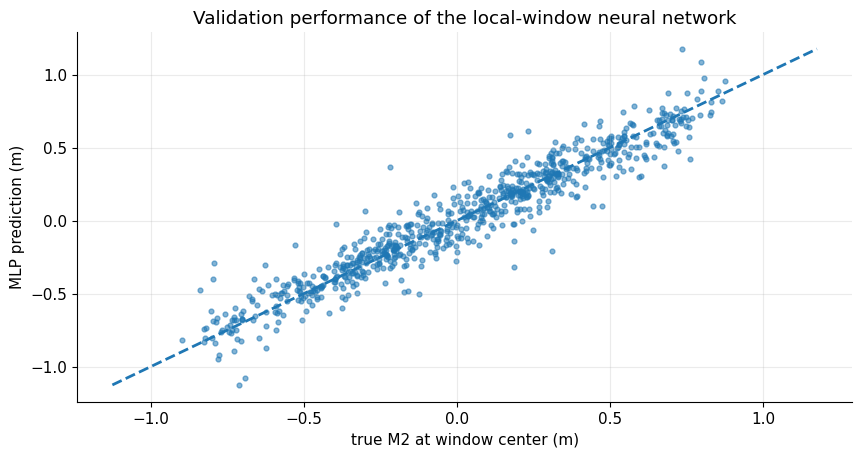

In [11]:
plt.figure()
plt.scatter(y_val, val_pred, s=12, alpha=0.55)
lims = [min(y_val.min(), val_pred.min()), max(y_val.max(), val_pred.max())]
plt.plot(lims, lims, linestyle="--", linewidth=2.0)
plt.xlabel("true M2 at window center (m)")
plt.ylabel("MLP prediction (m)")
plt.title("Validation performance of the local-window neural network")
plt.show()

## 5. Apply the trained MLP to the demonstration record

We now compare:
- **Harmonic least squares** (physics-informed, frequency known exactly)
- **Windowed MLP** (data-driven, no explicit frequency supplied)

In [12]:
mlp_demo = predict_mlp_record(mlp_model, demo, window=WINDOW)

comparison = pd.DataFrame(
    {
        "model": ["harmonic least squares", "windowed MLP"],
        "M2 RMSE (m)": [
            rmse(demo["m2_true"], harmonic["prediction"]),
            rmse(demo["m2_true"], mlp_demo),
        ],
        "variance explained": [
            variance_explained(demo["m2_true"], harmonic["prediction"]),
            variance_explained(demo["m2_true"], mlp_demo),
        ],
        "M2-band reduction (%)": [
            m2_band_reduction(demo["observed"], demo["observed"] - harmonic["prediction"], dt_hours=demo["dt_hours"]),
            m2_band_reduction(demo["observed"], demo["observed"] - mlp_demo, dt_hours=demo["dt_hours"]),
        ],
    }
)
comparison

,model,M2 RMSE (m),variance explained,M2-band reduction (%)
0,harmonic least squares,0.0069,0.9999,99.6581
1,windowed MLP,0.0701,0.9679,99.8720


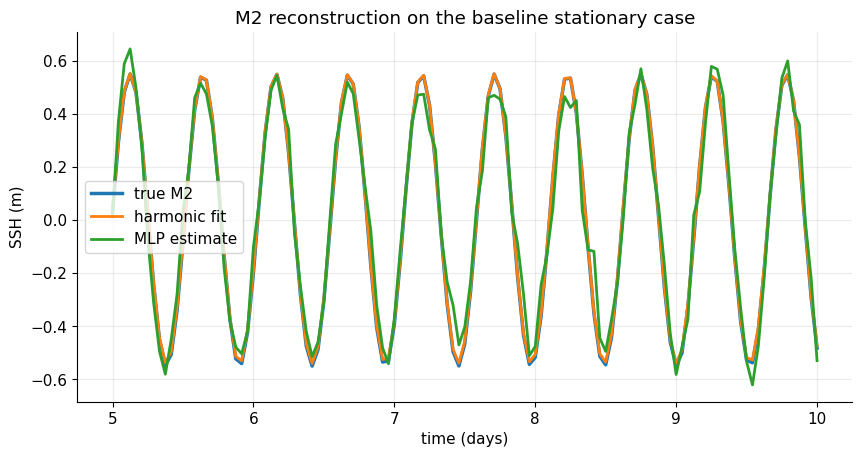

In [13]:
plt.figure()
plt.plot(demo["t_hours"][zoom] / 24.0, demo["m2_true"][zoom], label="true M2", linewidth=2.5)
plt.plot(demo["t_hours"][zoom] / 24.0, harmonic["prediction"][zoom], label="harmonic fit", linewidth=2.0)
plt.plot(demo["t_hours"][zoom] / 24.0, mlp_demo[zoom], label="MLP estimate", linewidth=2.0)
plt.xlabel("time (days)")
plt.ylabel("SSH (m)")
plt.title("M2 reconstruction on the baseline stationary case")
plt.legend()
plt.show()

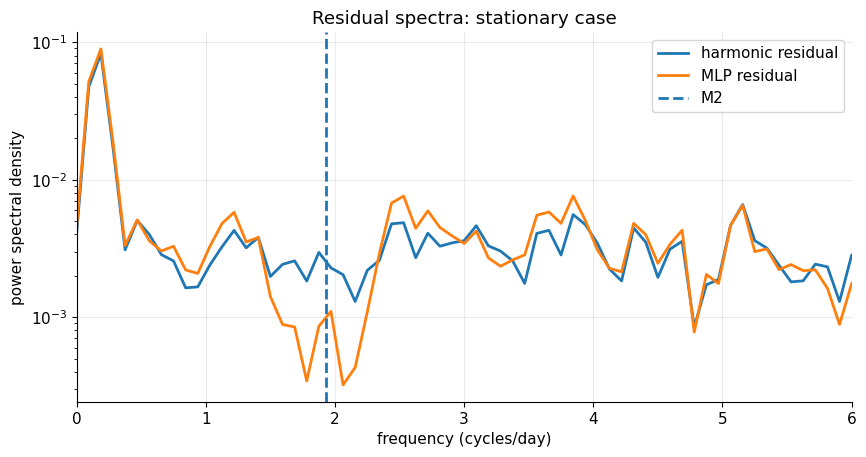

In [14]:
harmonic_residual = demo["observed"] - harmonic["prediction"]
mlp_residual = demo["observed"] - mlp_demo

freq_harm, psd_harm = spectrum_cpd(harmonic_residual, dt_hours=demo["dt_hours"])
freq_mlp, psd_mlp = spectrum_cpd(mlp_residual, dt_hours=demo["dt_hours"])

plt.figure()
plt.semilogy(freq_harm, psd_harm, label="harmonic residual", linewidth=2.0)
plt.semilogy(freq_mlp, psd_mlp, label="MLP residual", linewidth=2.0)
plt.axvline(M2_FREQUENCY_CPD, linestyle="--", linewidth=2.0, label="M2")
plt.xlim(0, 6)
plt.xlabel("frequency (cycles/day)")
plt.ylabel("power spectral density")
plt.title("Residual spectra: stationary case")
plt.legend()
plt.show()

### Interpretation so far

For this first, idealized case:
- the M2 frequency is correct,
- the M2 amplitude is stationary,
- there are no gaps.

That setup is favorable to the classical harmonic fit, so it should not be surprising that the harmonic method is the best performer. This is the right scientific conclusion: **when the model assumptions are correct, classical methods are extremely strong**.

## 6. Stress tests

The next question is more interesting:

> What happens when the assumptions of the classical model are not exactly right?

We test four cases:
1. increasing noise,
2. missing data,
3. slight frequency mismatch between the assumed and actual oscillation,
4. nonstationary M2 amplitude.

The MLP was trained on a mixture of noisy, gappy, and slightly perturbed synthetic records, so it may be more robust to some types of mismatch.

In [15]:
def noise_sweep(model, noise_values, seed=100):
    rows = []
    for noise_std in noise_values:
        rec = generate_synthetic_record(
            days=45,
            dt_hours=1.0,
            m2_amplitude=0.55,
            m2_phase_deg=35.0,
            noise_std=noise_std,
            low_freq_amplitude=0.22,
            seed=seed,
        )
        ev = evaluate_record_models(rec, model)
        rows.append(
            {
                "noise std (m)": noise_std,
                "harmonic RMSE (m)": ev["rmse_harmonic"],
                "MLP RMSE (m)": ev["rmse_mlp"],
            }
        )
    return pd.DataFrame(rows)


noise_df = noise_sweep(mlp_model, [0.05, 0.10, 0.18, 0.30, 0.45], seed=321)
noise_df

,noise std (m),harmonic RMSE (m),MLP RMSE (m)
0,0.0500,0.0041,0.0519
1,0.1000,0.0080,0.0595
2,0.1800,0.0141,0.0766
3,0.3000,0.0234,0.1123
4,0.4500,0.0349,0.1663


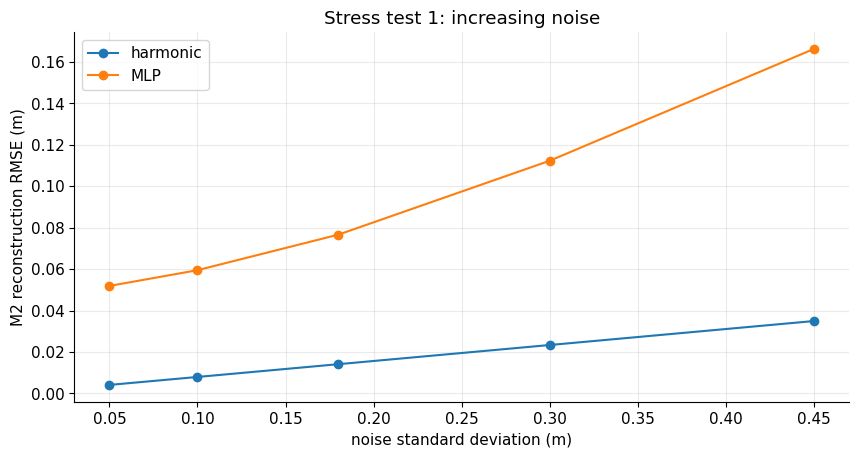

In [16]:
plt.figure()
plt.plot(noise_df["noise std (m)"], noise_df["harmonic RMSE (m)"], marker="o", label="harmonic")
plt.plot(noise_df["noise std (m)"], noise_df["MLP RMSE (m)"], marker="o", label="MLP")
plt.xlabel("noise standard deviation (m)")
plt.ylabel("M2 reconstruction RMSE (m)")
plt.title("Stress test 1: increasing noise")
plt.legend()
plt.show()

In [17]:
def gap_sweep(model, gap_values, seed=100):
    rows = []
    for missing_fraction in gap_values:
        rec = generate_synthetic_record(
            days=45,
            dt_hours=1.0,
            m2_amplitude=0.55,
            m2_phase_deg=35.0,
            noise_std=0.18,
            low_freq_amplitude=0.22,
            missing_fraction=missing_fraction,
            seed=seed,
        )
        ev = evaluate_record_models(rec, model)
        rows.append(
            {
                "missing fraction": missing_fraction,
                "harmonic RMSE (m)": ev["rmse_harmonic"],
                "MLP RMSE (m)": ev["rmse_mlp"],
            }
        )
    return pd.DataFrame(rows)


gap_df = gap_sweep(mlp_model, [0.00, 0.10, 0.20, 0.35], seed=321)
gap_df

,missing fraction,harmonic RMSE (m),MLP RMSE (m)
0,0.0000,0.0141,0.0766
1,0.1000,0.0158,0.1009
2,0.2000,0.0189,0.1260
3,0.3500,0.0198,0.1560


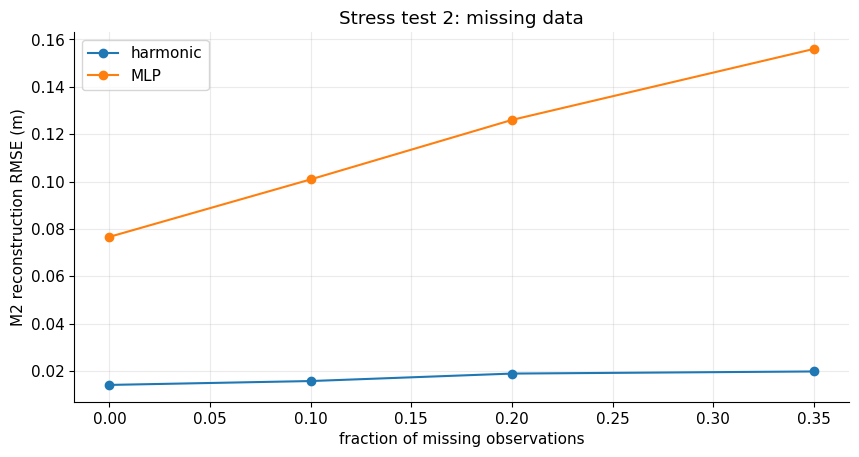

In [18]:
plt.figure()
plt.plot(gap_df["missing fraction"], gap_df["harmonic RMSE (m)"], marker="o", label="harmonic")
plt.plot(gap_df["missing fraction"], gap_df["MLP RMSE (m)"], marker="o", label="MLP")
plt.xlabel("fraction of missing observations")
plt.ylabel("M2 reconstruction RMSE (m)")
plt.title("Stress test 2: missing data")
plt.legend()
plt.show()

In [19]:
def mismatch_sweep(model, freq_scales, seed=100):
    rows = []
    for freq_scale in freq_scales:
        rec = generate_synthetic_record(
            days=45,
            dt_hours=1.0,
            m2_amplitude=0.55,
            m2_phase_deg=35.0,
            noise_std=0.18,
            low_freq_amplitude=0.22,
            freq_scale=freq_scale,
            seed=seed,
        )
        ev = evaluate_record_models(rec, model, harmonic_omega=M2_OMEGA)
        rows.append(
            {
                "true frequency scale": freq_scale,
                "frequency error (%)": 100.0 * (freq_scale - 1.0),
                "harmonic RMSE (m)": ev["rmse_harmonic"],
                "MLP RMSE (m)": ev["rmse_mlp"],
            }
        )
    return pd.DataFrame(rows)


mismatch_df = mismatch_sweep(mlp_model, [1.000, 1.001, 1.002, 1.004, 1.006], seed=321)
mismatch_df

,true frequency scale,frequency error (%),harmonic RMSE (m),MLP RMSE (m)
0,1.0000,0.0000,0.0141,0.0766
1,1.0010,0.1000,0.0627,0.0753
2,1.0020,0.2000,0.1213,0.0739
3,1.0040,0.4000,0.2278,0.0735
4,1.0060,0.6000,0.3094,0.0737


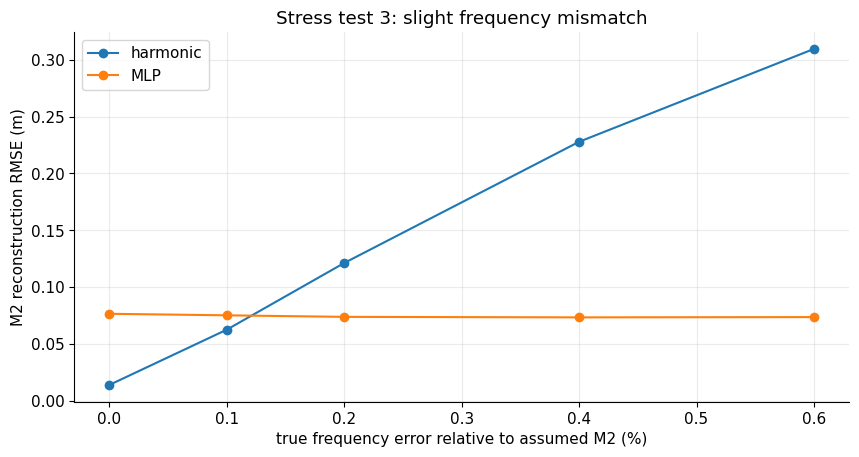

In [20]:
plt.figure()
plt.plot(mismatch_df["frequency error (%)"], mismatch_df["harmonic RMSE (m)"], marker="o", label="harmonic")
plt.plot(mismatch_df["frequency error (%)"], mismatch_df["MLP RMSE (m)"], marker="o", label="MLP")
plt.xlabel("true frequency error relative to assumed M2 (%)")
plt.ylabel("M2 reconstruction RMSE (m)")
plt.title("Stress test 3: slight frequency mismatch")
plt.legend()
plt.show()

In [21]:
modulated = generate_synthetic_record(
    days=45,
    dt_hours=1.0,
    m2_amplitude=0.55,
    m2_phase_deg=35.0,
    noise_std=0.18,
    low_freq_amplitude=0.22,
    amplitude_modulation=True,
    seed=321,
)

mod_harmonic = fit_harmonic_ls(modulated["t_hours"], modulated["observed"], omega=M2_OMEGA)
mod_mlp = predict_mlp_record(mlp_model, modulated, window=WINDOW)

mod_metrics = pd.DataFrame(
    {
        "model": ["harmonic least squares", "windowed MLP"],
        "M2 RMSE (m)": [
            rmse(modulated["m2_true"], mod_harmonic["prediction"]),
            rmse(modulated["m2_true"], mod_mlp),
        ],
        "variance explained": [
            variance_explained(modulated["m2_true"], mod_harmonic["prediction"]),
            variance_explained(modulated["m2_true"], mod_mlp),
        ],
    }
)
mod_metrics

,model,M2 RMSE (m),variance explained
0,harmonic least squares,0.0818,0.9580
1,windowed MLP,0.0778,0.9623


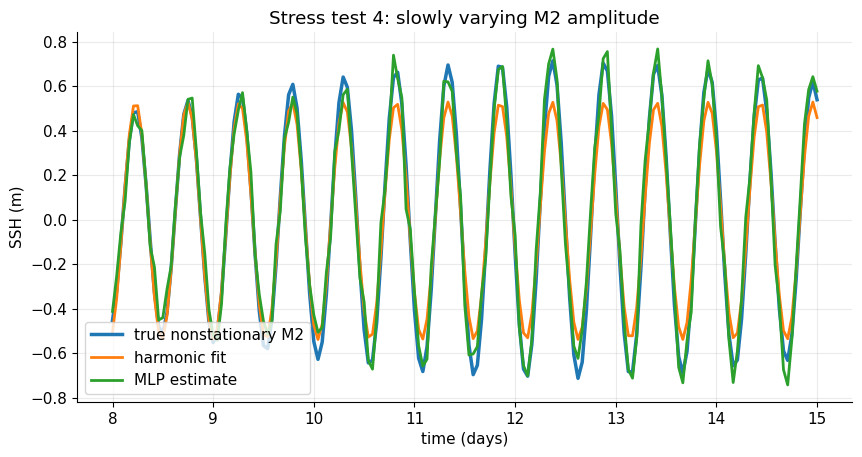

In [22]:
mod_zoom = (modulated["t_hours"] >= 8 * 24) & (modulated["t_hours"] <= 15 * 24)

plt.figure()
plt.plot(modulated["t_hours"][mod_zoom] / 24.0, modulated["m2_true"][mod_zoom], label="true nonstationary M2", linewidth=2.5)
plt.plot(modulated["t_hours"][mod_zoom] / 24.0, mod_harmonic["prediction"][mod_zoom], label="harmonic fit", linewidth=2.0)
plt.plot(modulated["t_hours"][mod_zoom] / 24.0, mod_mlp[mod_zoom], label="MLP estimate", linewidth=2.0)
plt.xlabel("time (days)")
plt.ylabel("SSH (m)")
plt.title("Stress test 4: slowly varying M2 amplitude")
plt.legend()
plt.show()

### What the stress tests show

- **More noise:** the harmonic fit remains excellent in this stationary single-constituent problem.
- **Missing data:** the harmonic fit is also very robust when enough valid data remain.
- **Frequency mismatch:** the harmonic fit degrades rapidly because it assumes the wrong narrowband frequency; the MLP is much more tolerant.
- **Nonstationary amplitude:** the single global harmonic fit cannot track a slowly varying envelope, while the local-window MLP can adapt better.

That is exactly the trade-off we wanted to expose:
- **classical methods win when their assumptions are right;**
- **ML can be more flexible when those assumptions are violated.**

## 7. Residual analysis on the frequency-mismatch case

This is the most informative failure mode in the notebook, because it shows a case where the MLP can outperform the classical baseline.

In [23]:
mismatch_case = generate_synthetic_record(
    days=45,
    dt_hours=1.0,
    m2_amplitude=0.55,
    m2_phase_deg=35.0,
    noise_std=0.18,
    low_freq_amplitude=0.22,
    freq_scale=1.004,
    seed=456,
)

mismatch_harmonic = fit_harmonic_ls(mismatch_case["t_hours"], mismatch_case["observed"], omega=M2_OMEGA)
mismatch_mlp = predict_mlp_record(mlp_model, mismatch_case, window=WINDOW)

mismatch_comparison = pd.DataFrame(
    {
        "model": ["harmonic least squares", "windowed MLP"],
        "M2 RMSE (m)": [
            rmse(mismatch_case["m2_true"], mismatch_harmonic["prediction"]),
            rmse(mismatch_case["m2_true"], mismatch_mlp),
        ],
        "variance explained": [
            variance_explained(mismatch_case["m2_true"], mismatch_harmonic["prediction"]),
            variance_explained(mismatch_case["m2_true"], mismatch_mlp),
        ],
        "M2-band reduction (%)": [
            m2_band_reduction(
                mismatch_case["observed"],
                mismatch_case["observed"] - mismatch_harmonic["prediction"],
                dt_hours=mismatch_case["dt_hours"],
            ),
            m2_band_reduction(
                mismatch_case["observed"],
                mismatch_case["observed"] - mismatch_mlp,
                dt_hours=mismatch_case["dt_hours"],
            ),
        ],
    }
)
mismatch_comparison

,model,M2 RMSE (m),variance explained,M2-band reduction (%)
0,harmonic least squares,0.2274,0.6578,76.0145
1,windowed MLP,0.0664,0.9712,99.8866


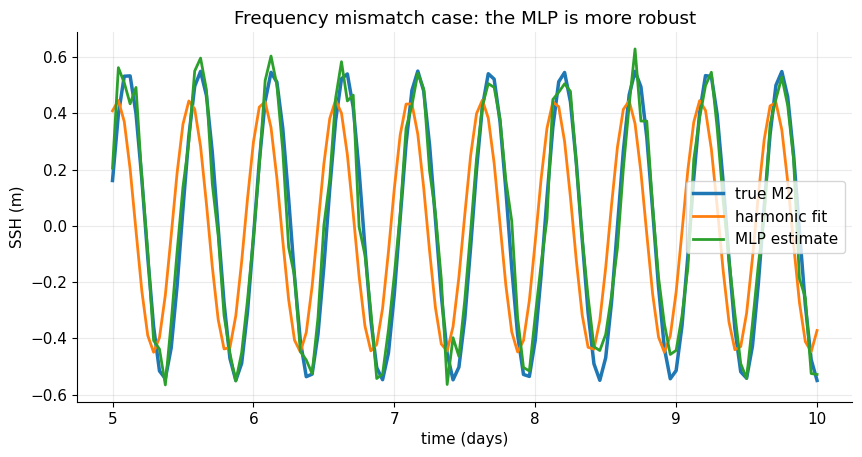

In [24]:
mis_zoom = (mismatch_case["t_hours"] >= 5 * 24) & (mismatch_case["t_hours"] <= 10 * 24)

plt.figure()
plt.plot(mismatch_case["t_hours"][mis_zoom] / 24.0, mismatch_case["m2_true"][mis_zoom], label="true M2", linewidth=2.5)
plt.plot(mismatch_case["t_hours"][mis_zoom] / 24.0, mismatch_harmonic["prediction"][mis_zoom], label="harmonic fit", linewidth=2.0)
plt.plot(mismatch_case["t_hours"][mis_zoom] / 24.0, mismatch_mlp[mis_zoom], label="MLP estimate", linewidth=2.0)
plt.xlabel("time (days)")
plt.ylabel("SSH (m)")
plt.title("Frequency mismatch case: the MLP is more robust")
plt.legend()
plt.show()

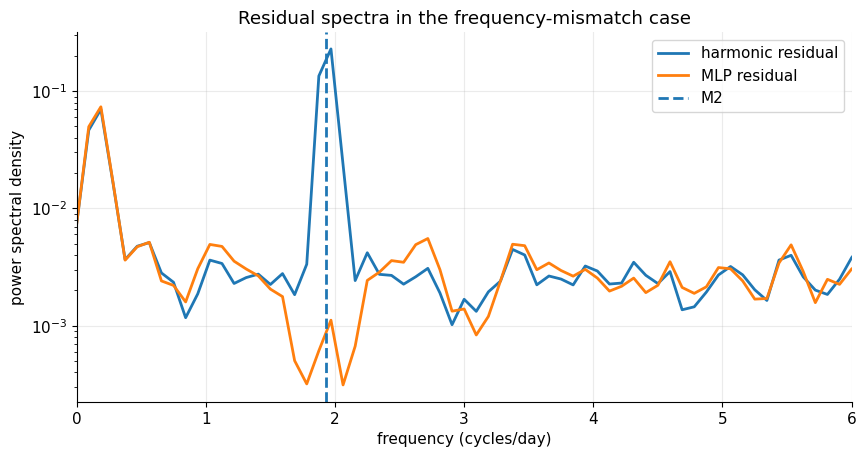

In [25]:
mis_harm_resid = mismatch_case["observed"] - mismatch_harmonic["prediction"]
mis_mlp_resid = mismatch_case["observed"] - mismatch_mlp

f_h, p_h = spectrum_cpd(mis_harm_resid, dt_hours=mismatch_case["dt_hours"])
f_m, p_m = spectrum_cpd(mis_mlp_resid, dt_hours=mismatch_case["dt_hours"])

plt.figure()
plt.semilogy(f_h, p_h, label="harmonic residual", linewidth=2.0)
plt.semilogy(f_m, p_m, label="MLP residual", linewidth=2.0)
plt.axvline(M2_FREQUENCY_CPD, linestyle="--", linewidth=2.0, label="M2")
plt.xlim(0, 6)
plt.xlabel("frequency (cycles/day)")
plt.ylabel("power spectral density")
plt.title("Residual spectra in the frequency-mismatch case")
plt.legend()
plt.show()

## 8. Exercises (with worked solutions)

These are written as **teaching exercises**, but each one is also fully implemented below so the notebook stays self-contained.

### Exercise 1 — Sampling interval and aliasing

**Prompt:** vary the sampling interval and determine when the M2 constituent becomes poorly represented or aliased.

Recall:
- sample rate \(f_s = 24/\Delta t\) cycles per day,
- Nyquist frequency \(f_N = f_s/2\),
- M2 is at about \(1.93\) cycles per day.

What happens as \(\Delta t\) approaches or exceeds about 6.2 hours?

In [26]:
alias_rows = []
for dt_hours in [0.5, 1.0, 3.0, 6.0, 10.0, 13.0]:
    fs_cpd = 24.0 / dt_hours
    nyquist_cpd = fs_cpd / 2.0
    alias_rows.append(
        {
            "sampling interval (h)": dt_hours,
            "sample rate (cpd)": fs_cpd,
            "Nyquist (cpd)": nyquist_cpd,
            "true M2 (cpd)": M2_FREQUENCY_CPD,
            "apparent aliased freq (cpd)": alias_frequency(M2_FREQUENCY_CPD, fs_cpd),
            "Nyquist violated?": M2_FREQUENCY_CPD > nyquist_cpd,
        }
    )

alias_df = pd.DataFrame(alias_rows)
alias_df

,sampling interval (h),sample rate (cpd),Nyquist (cpd),true M2 (cpd),apparent aliased freq (cpd),Nyquist violated?
0,0.5000,48.0000,24.0000,1.9323,1.9323,False
1,1.0000,24.0000,12.0000,1.9323,1.9323,False
2,3.0000,8.0000,4.0000,1.9323,1.9323,False
3,6.0000,4.0000,2.0000,1.9323,1.9323,False
4,10.0000,2.4000,1.2000,1.9323,0.4677,True
5,13.0000,1.8462,0.9231,1.9323,0.0861,True


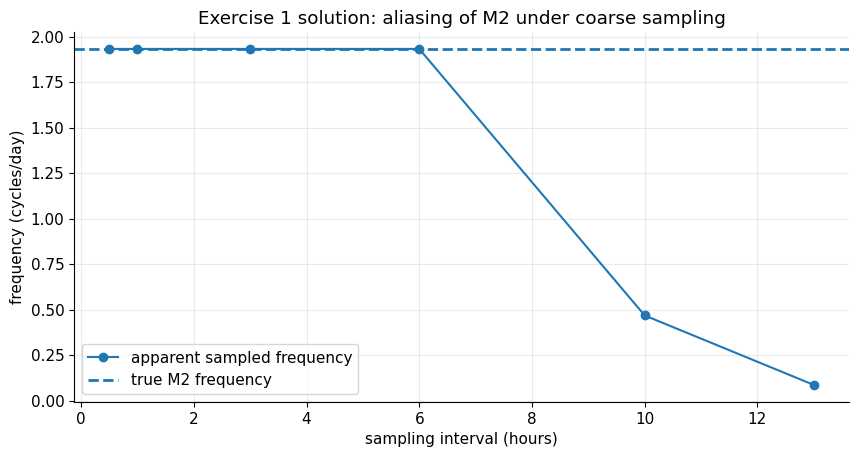

In [27]:
plt.figure()
plt.plot(alias_df["sampling interval (h)"], alias_df["apparent aliased freq (cpd)"], marker="o", label="apparent sampled frequency")
plt.axhline(M2_FREQUENCY_CPD, linestyle="--", linewidth=2.0, label="true M2 frequency")
plt.xlabel("sampling interval (hours)")
plt.ylabel("frequency (cycles/day)")
plt.title("Exercise 1 solution: aliasing of M2 under coarse sampling")
plt.legend()
plt.show()

### Exercise 2 — Add a second constituent (S2)

**Prompt:** add an S2 constituent and compare:
1. a single-frequency M2 fit,
2. a two-constituent M2 + S2 fit.

Question: what happens to the residual spectrum if you only remove M2?

In [28]:
two_constituent = generate_synthetic_record(
    days=45,
    dt_hours=1.0,
    m2_amplitude=0.45,
    m2_phase_deg=20.0,
    noise_std=0.12,
    low_freq_amplitude=0.10,
    s2_amplitude=0.15,
    seed=777,
)

m2_only = fit_harmonic_ls(two_constituent["t_hours"], two_constituent["observed"], omega=M2_OMEGA)
m2_s2 = fit_multifrequency_ls(two_constituent["t_hours"], two_constituent["observed"], omegas=[M2_OMEGA, S2_OMEGA])

resid_m2_only = two_constituent["observed"] - m2_only["prediction"]
resid_m2_s2 = two_constituent["observed"] - m2_s2["prediction"]

exercise2_metrics = pd.DataFrame(
    {
        "model": ["M2 only", "M2 + S2"],
        "residual RMSE vs observed-minus-low-frequency (m)": [
            rmse(two_constituent["observed_no_gaps"] - two_constituent["low_true"], m2_only["prediction"]),
            rmse(two_constituent["observed_no_gaps"] - two_constituent["low_true"], m2_s2["prediction"]),
        ],
    }
)
exercise2_metrics

,model,residual RMSE vs observed-minus-low-frequency (m)
0,M2 only,0.1591
1,M2 + S2,0.1224


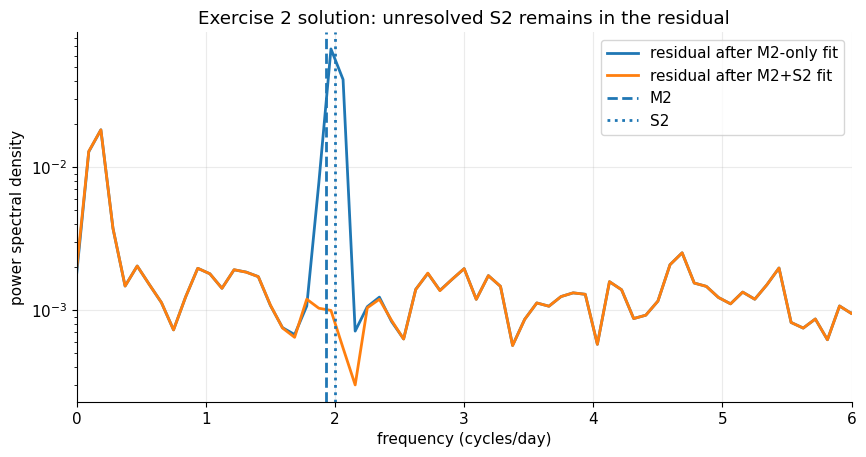

In [29]:
f0, p0 = spectrum_cpd(resid_m2_only, dt_hours=two_constituent["dt_hours"])
f1, p1 = spectrum_cpd(resid_m2_s2, dt_hours=two_constituent["dt_hours"])

plt.figure()
plt.semilogy(f0, p0, label="residual after M2-only fit", linewidth=2.0)
plt.semilogy(f1, p1, label="residual after M2+S2 fit", linewidth=2.0)
plt.axvline(M2_FREQUENCY_CPD, linestyle="--", linewidth=2.0, label="M2")
plt.axvline(S2_FREQUENCY_CPD, linestyle=":", linewidth=2.0, label="S2")
plt.xlim(0, 6)
plt.xlabel("frequency (cycles/day)")
plt.ylabel("power spectral density")
plt.title("Exercise 2 solution: unresolved S2 remains in the residual")
plt.legend()
plt.show()

### Exercise 3 — Domain shift / failure mode

**Prompt:** evaluate the trained MLP on amplitudes **outside the training distribution**.

In training, the synthetic M2 amplitudes were drawn from roughly **0.20–0.90 m**.  
What happens if the true M2 amplitude is much smaller?

In [30]:
domain_rows = []
for amp in [0.05, 0.10, 0.20, 0.40, 0.70, 1.00]:
    rec = generate_synthetic_record(
        days=45,
        dt_hours=1.0,
        m2_amplitude=amp,
        m2_phase_deg=35.0,
        noise_std=0.18,
        low_freq_amplitude=0.22,
        seed=910,
    )
    ev = evaluate_record_models(rec, mlp_model, window=WINDOW)
    domain_rows.append(
        {
            "true M2 amplitude (m)": amp,
            "harmonic RMSE (m)": ev["rmse_harmonic"],
            "MLP RMSE (m)": ev["rmse_mlp"],
            "MLP variance explained": ev["ve_mlp"],
        }
    )

domain_df = pd.DataFrame(domain_rows)
domain_df

,true M2 amplitude (m),harmonic RMSE (m),MLP RMSE (m),MLP variance explained
0,0.0500,0.0110,0.0776,-3.8009
1,0.1000,0.0110,0.0764,-0.1622
2,0.2000,0.0110,0.0723,0.7410
3,0.4000,0.0110,0.0689,0.9413
4,0.7000,0.0110,0.0787,0.9750
5,1.0000,0.0110,0.0947,0.9822


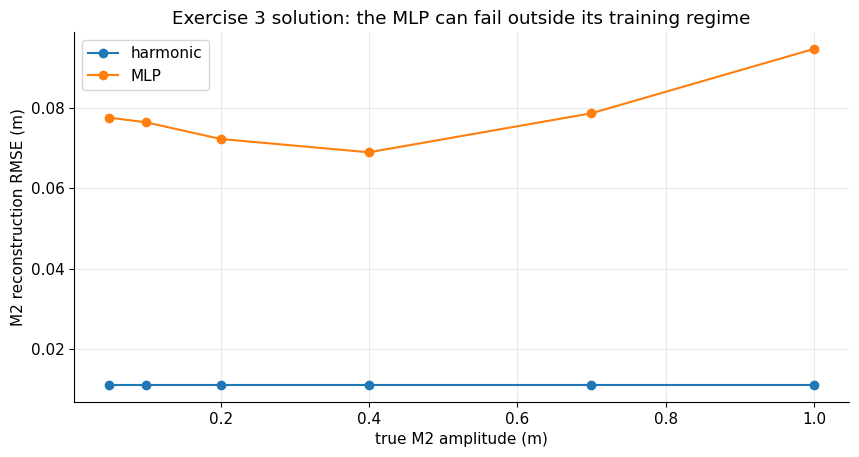

In [31]:
plt.figure()
plt.plot(domain_df["true M2 amplitude (m)"], domain_df["harmonic RMSE (m)"], marker="o", label="harmonic")
plt.plot(domain_df["true M2 amplitude (m)"], domain_df["MLP RMSE (m)"], marker="o", label="MLP")
plt.xlabel("true M2 amplitude (m)")
plt.ylabel("M2 reconstruction RMSE (m)")
plt.title("Exercise 3 solution: the MLP can fail outside its training regime")
plt.legend()
plt.show()

## 9. Main takeaways

1. **M2 is a deterministic narrowband constituent**, so classical harmonic analysis is extremely effective when the constituent frequency is correct and the amplitude is stationary.
2. In that ideal case, the harmonic fit is usually the best method in this notebook.
3. A **windowed neural network** can still learn the M2 structure from noisy data **without being explicitly told the M2 frequency**.
4. The MLP becomes attractive when the classical assumptions are violated:
   - mild frequency mismatch,
   - slow nonstationarity,
   - some forms of contamination learned during training.
5. **ML is not magic**:
   - it can fail under domain shift,
   - it depends on the realism of the training distribution,
   - it should be benchmarked against classical methods, not replace them blindly.

## Ways to extend this notebook

- Replace the single constituent with a full multi-constituent harmonic model.
- Add red noise, stochastic mesoscale variability, or colored instrument noise.
- Use real tide-gauge or along-track altimetry data and compare against an operational tide model.
- Replace the MLP with a 1D CNN, temporal convolutional network, or transformer encoder and compare cost vs gain.

---
**Bottom line:** for tide subtraction problems, the scientifically honest workflow is usually  
**classical harmonic baseline first, ML second, and always compare residual spectra.**